In [10]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [11]:
# --- YOUR GROUP'S STATION ---
site_number = '09498500'   # ← replace with your station

In [12]:
url = "https://waterservices.usgs.gov/nwis/dv/"
params = {
    "format": "json",
    "sites": site_number,
    "parameterCd": "00060",     # 00060 = streamflow (ft³/s)
    "startDT": "2020-01-01",
    "endDT":   "2024-12-31",
    "siteStatus": "all"
}

In [13]:
# Make the request
response = requests.get(url, params=params)
data = response.json()

In [14]:
# Parse — the response is nested JSON; this navigates to the values
records = data["value"]["timeSeries"][0]["values"][0]["value"]
df = pd.DataFrame(records)
df["dateTime"] = pd.to_datetime(df["dateTime"])
df["value"]    = pd.to_numeric(df["value"], errors="coerce")
df = df.set_index("dateTime")

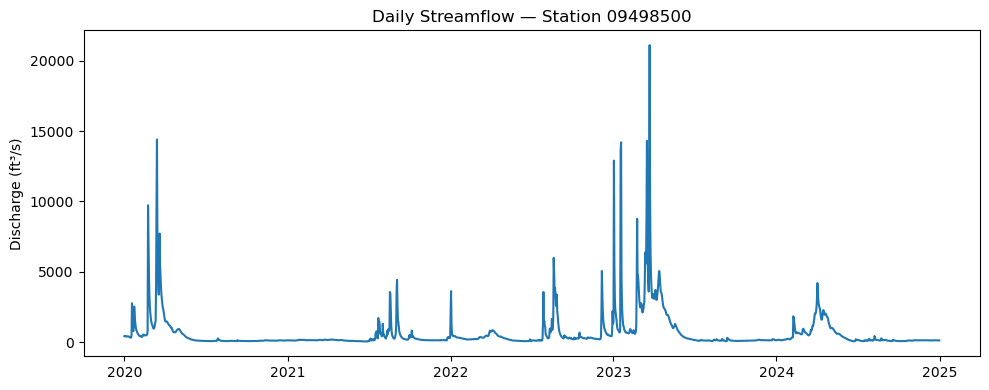

<Figure size 640x480 with 0 Axes>

In [15]:
# Plot
plt.figure(figsize=(10, 4))
plt.plot(df.index, df["value"])
plt.title(f"Daily Streamflow — Station {site_number}")
plt.ylabel("Discharge (ft³/s)")
plt.tight_layout()
plt.show()
plt.savefig(f"streamflow_{site_number}.png", dpi=300)